---
title: "Barycentric formula and divided differences"
subtitle: "Lecture 8: Chapter 3: Polynomial interpolation"
code-fold: true
format:
  html: default
  pdf: default
---

{{< include ../extras/_lecture-header.html >}}

::: {.callout-note}

**Note.**  These notes are mainly a record of what we discussed and are not a substitute for attending the lectures and reading books! If anything is unclear/wrong, let me know and I will update the notes.
 
:::


In [1]:
# | include: false

using Plots, LaTeXStrings, Polynomials, Printf 

## Previously.....

- Interpolation, Taylor expansion, Lagrange interpolation, 
- Thm: there exists a unique polynomial $p \in \mathcal P_n$ solving Lagrange interpolation problem on $n+1$ distinct nodes, 
- Proof: uses Lagrange polynomials $\ell_j(x) = \prod_{k\not=j} (x-x_k)/(x_j-x_k)$, 
- Error estimate: Taylor-like remainder estimate depending on derivatives of $f$ and the *node polynomial* $\ell_X(x) = (x-x_0)(x-x_1) \dots (x-x_n)$, 
- Runge: Equispaced points bad, 
- Chebyshev nodes much better, 
- Chebyshev nodes of the first kind minimise $\| \ell_X \|_{L^\infty([-1,1])} = 2^{-n}$ (where $X$ has $n+1$ nodes), 
- Proof: Chebyshev polynomials (of the first kind) solve the *Chebyshev problem*,
- Chebyshev nodes of the second kind give $\| \ell_X \|_{L^\infty([-1,1])} = 2^{1-n}$,

::: {.box}

**Exercise.** @exr-l07-XII

:::


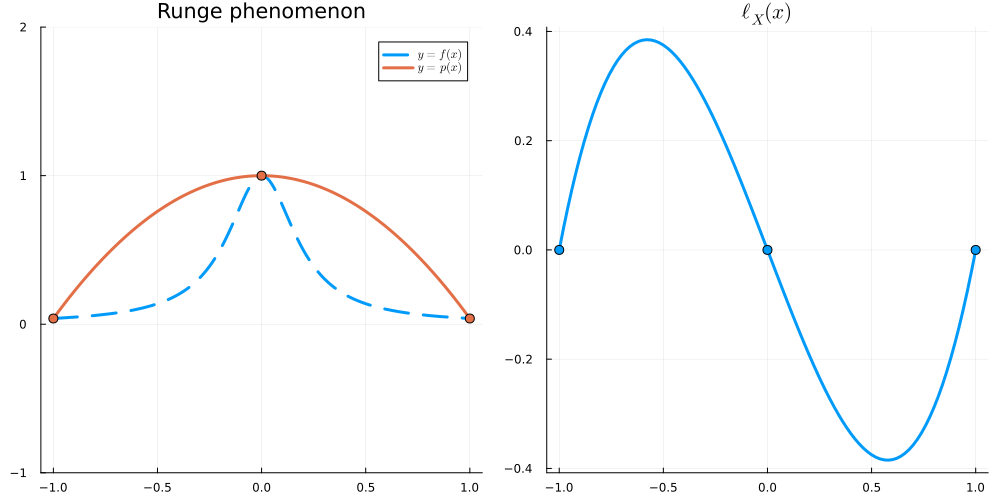


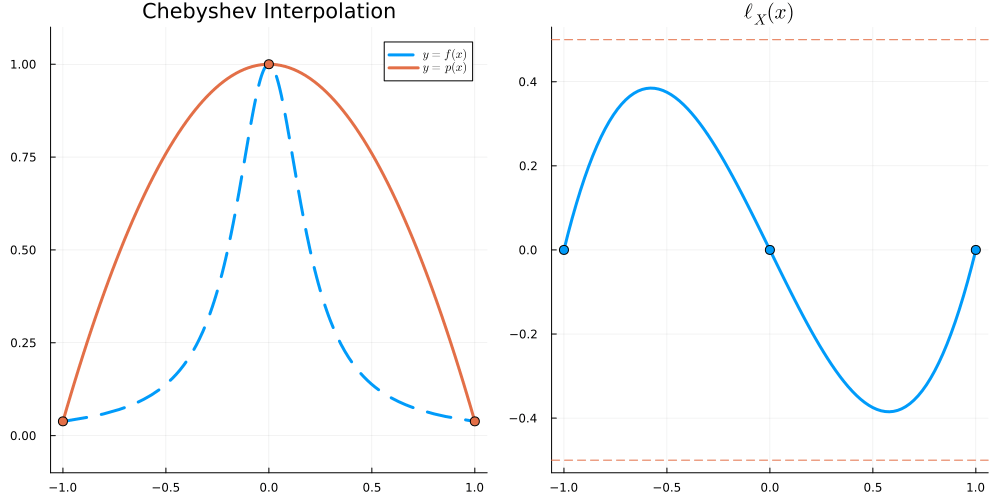



## Barycentric formula

See e.g. @BerrutTrefethen2004 [link](https://people.maths.ox.ac.uk/trefethen/barycentric.pdf) for more details.  

::: {#exr-Bary-1}

Let's use the formula

$$
\begin{align}
    I_Xf(x) &= \sum_{j=0}^n f(x_j) \ell_j(x), \\
    %
    \ell_j(x) &:= \prod_{k\not=j} \frac{x - x_k}{x_j - x_k} \nonumber
\end{align}
$$ {#eq-interpolation-naive}

to compute the polynomial interpolation of $f(x) = \frac1{1+25x^2}$ (Runge function, as above):

Plots.AnimatedGif("/home/thom9218/Math5485/images/Naive Lagrange.gif")
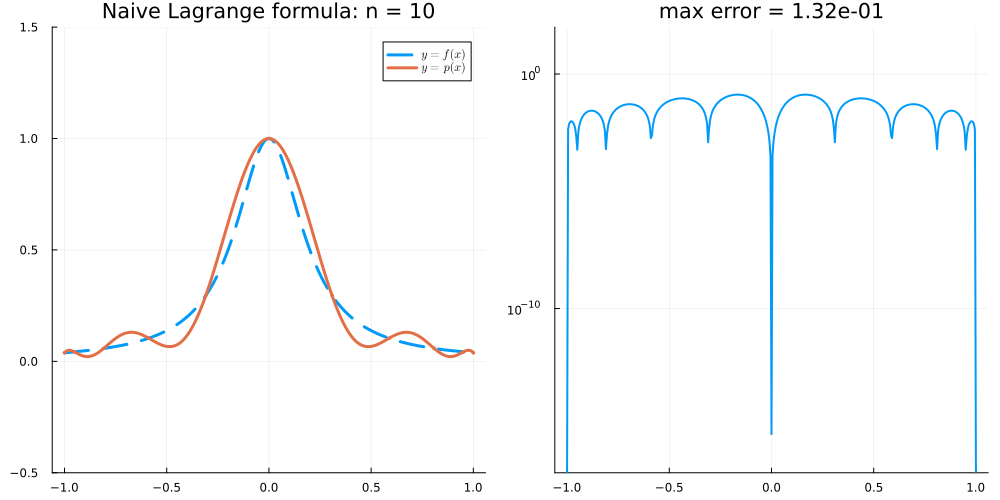

In [2]:
#| classes: animation

Runge = t -> 1/(1 + 25t^2)

function ℓⱼ( j, t, x ) 
    if j == 0
        return prod( @. t - x[2:end] ) / prod( @. x[1] - x[2:end] )
    elseif j == length(x)-1 
        return prod( @. t - x[1:end-1] ) / prod( @. x[end] - x[1:end-1] )
    else
        return prod( @. t - x[1:j] ) * prod( @. t - x[(j+2):end] ) / ( prod( @. x[j+1] - x[1:j] ) * prod( @. x[j+1] - x[(j+2):end] ) )
    end
end 

function p_naive( t, x, y ) 
    r = 0
    for j in 0:(length(x)-1)
        r = r + ℓⱼ(j, t, x) * y[j+1] 
    end
    return r
end 

egrid = range(-1, 1, length=401)

anim = @animate for n ∈ [10, 20, 50, 100, 200, 400, 600, 700, 760, 780:20:1020...]
    x = @. cos( π*(0:n)/n )
    y = @. Runge( x )
    p = p_naive.( egrid, Ref(x), Ref(y) )
    err = @. max( abs( p - Runge(egrid) ), 1e-17 )

    plt1 = plot(Runge, -1, 1; label=L"y = f(x)", lw = 3, linestyle = :dash, 
            title = "Naive Lagrange formula: n = $n", ylims = (-0.5, 1.5))
    plot!(plt1, egrid, p; label=L"y = p(x)", lw = 3 )
    scatter!(plt1, x, y; primary = false, markersize = 2, markerstrokewidth = 0)

    plt2 = plot(egrid, err; yscale = :log10, ylims = (1e-17, 1e2), legend = false, lw = 2,
            title = @sprintf("max error = %.2e", maximum(err)))
    plot( plt1, plt2; size=(1000, 500) )
end

gif(anim, "../images/Naive Lagrange.gif", fps = 1, show_msg = false)



What is happening here?

::: {.exercise-hint style="display:none;"}

Subtractive cancellation!

:::

:::


Notice also that, in order to compute @eq-interpolation-naive, we need $O(n^2)$ function evaluations for each $x$ - so it is slow and unstable!

Instead, we may use the *Barycentric formula* which we now derive. First notice that 

$$
\begin{align}
    \ell_j(x) &= \prod_{k \not= j} \frac{x - x_k}{x_j - x_k} 
    \nonumber\\
    %
    &= \lambda_j \frac{\ell_X(x)}{x- x_j}
\end{align}
$$ {#eq-ell-j}

where $\lambda_j := \frac{1}{ \prod_{k \not= j} (x_j - x_k) }$. As a result, we have 

\begin{align}
    I_Xf(x) &= \sum_{j=0}^n f(x_j) \ell_j(x) \nonumber \\
    %
    &= \ell_X(x) \sum_{j=0}^n \frac{\lambda_j f(x_j)}{x- x_j}.
\end{align}

This is sometimes referred to as the *first form of the Barycentric formula*.

::: {#exr-sum-lagrange-1}

Suppose that $X = \{ x_0 < ... < x_n \}$ and let $\ell_j$ be the corresponding Lagrange polynomials. Show that $\sum_{j=0}^n \ell_j(x) = 1$ for all $x$.

:::

Therefore, using @eq-ell-j and dividing by $\sum_{j=0}^n \ell_j(x) = 1$, we obtain

$$
\begin{align}
    I_Xf(x) &= \left. \sum_{j=0}^n \ell_j(x) f(x_j) \middle/ \sum_{j=0}^n \ell_j(x) \right. \nonumber\\
    &= \left. \ell_X(x) \sum_{j=0}^n \frac{\lambda_j f(x_j)}{x - x_j} \middle/ \ell_X(x) \sum_{j=0}^n \frac{\lambda_j}{x - x_j} \right. \nonumber\\
    &= \left. \sum_{j=0}^n \frac{\lambda_j f(x_j)}{x - x_j} \middle/ \sum_{j=0}^n \frac{\lambda_j}{x - x_j} \right.
\end{align}
$$ {#eq-Barycentric}

which is known as the *Barycentric formula*. 

For a fixed interpolation set, one may compute $\lambda_j$ once and then evaluating $p(x)$ requires only $O(n)$ computations. 

In fact, for Chebyshev nodes $X_{\mathrm{II}} = \big\{ \cos \frac{j\pi}{n} \big\}_{j=0}^n$, we have a simple formula for the $\lambda_j$:

$$
\begin{align}
    \lambda_j = \begin{cases}
        \frac{2^{n}}{4n}  & \text{if } j = 0\nonumber\\
        (-1)^j \frac{2^{n}}{2n} & \text{if } j = 1,\dots,n-1 \nonumber\\
        (-1)^n \frac{2^{n}}{4n} & \text{if } j = n
    \end{cases}
\end{align}
$$ {#eq-Barycentric-Chebyshev-II}

::: {#exr-Bary-weights}

Explain why one may instead consider any weights of the form $w_j := C \lambda_j$ in the Barycentric formula @eq-Barycentric. Why might this be a good idea? See @eq-Barycentric-Chebyshev-II for the weights appearing in the Barycentric formula for Chebyshev nodes of the second kind.

:::

In particular, for Chebyshev nodes of the second kind, we can use @eq-Barycentric with the weights $w_j := (-1)^j \tau_j$ where $\tau_j = \frac12$ for $j=0, n$ and $\tau_j = 1$ otherwise. Moreover, this formula has been proved to be numerically stable (@Higham2004) which we demonstrate in the following:

Plots.AnimatedGif("/home/thom9218/Math5485/images/Barycentric.gif")
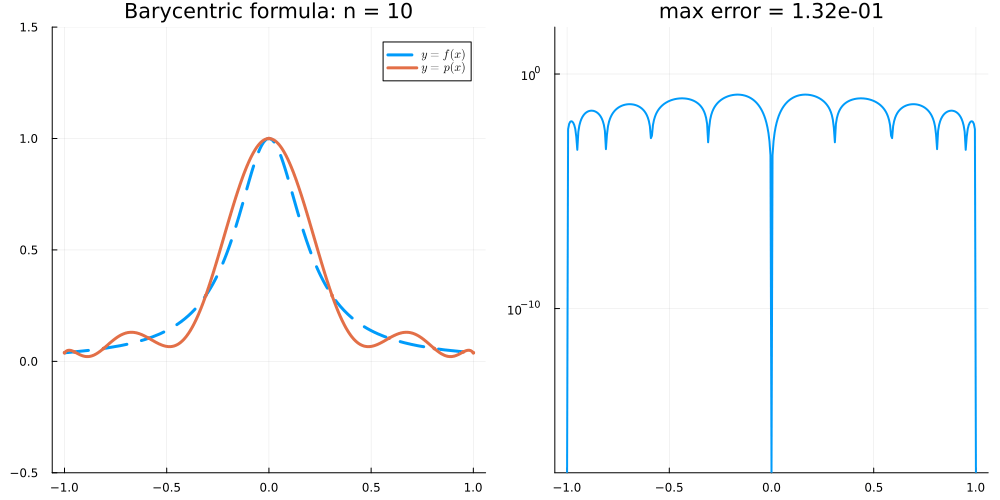

In [4]:
#| classes: animation

# Barycentric formula for Chebyshev nodes of the second kind:
function ChebyshevInterpolant( f, n )
    x = @. cos( π*(0:n)/n )
    y = @. f( x )
    λ = @. (-1.0)^(0:n)
    λ[1] /= 2
    λ[end] /= 2

    return function ( t )
        num = 0.0
        den = 0.0
        for j ∈ 1:(n+1)
            if t == x[j]
                return y[j]
            end
            num += λ[j] * y[j] / (t - x[j])
            den += λ[j] / (t - x[j])
        end
        return num / den
    end
end

egrid = range(-1, 1, length=401)

anim = @animate for n ∈ [10, 20, 50, 100, 200, 400, 600, 700, 760, 780:20:1020..., 1500, 2000, 5000, 10000]
    x = @. cos( π*(0:n)/n )
    p = ChebyshevInterpolant( Runge, n ).( egrid )
    err = @. max( abs( p - Runge(egrid) ), 1e-17 )

    plt1 = plot(Runge, -1, 1; label=L"y = f(x)", lw = 3, linestyle = :dash, 
            title = "Barycentric formula: n = $n", ylims = (-0.5, 1.5))
    plot!(plt1, egrid, p; label=L"y = p(x)", lw = 3 )
    scatter!(plt1, x, Runge.(x); primary = false, markersize = 2, markerstrokewidth = 0)

    plt2 = plot(egrid, err; yscale = :log10, ylims = (1e-17, 1e2), legend = false, lw = 2,
            title = @sprintf("max error = %.2e", maximum(err)))
    plot( plt1, plt2; size=(1000, 500) )
end

gif(anim, "../images/Barycentric.gif", fps = 1, show_msg = false)


::: {#exr-Bary-2}

Recall that the degree $2$ polynomial interpolation of $f(x) = \sin x$ on $X = \{ x_0 < x_1 < x_2 \} = \{ 0, \frac\pi2, \pi \}$ is $I_X f(x) = -\frac4{\pi^2} x(x-\pi)$. Write the Barycentric version of this formula @eq-Barycentric.

Explain how you would have to update this formula if we added an extra point $x_{3} = -2\pi$ to the interpolation set.

::: {.exercise-solution}

The Barycentric formula @eq-Barycentric depends on the weights $\lambda_j = \prod_{k\not=j} (x_j-x_k)^{-1}$ which in this case are given by 

\begin{align}
    \lambda_0 &= \frac{1}{(0-\frac\pi2)(0-\pi)} = \frac2{\pi^2}, \nonumber\\
    \lambda_1 &= \frac{1}{(\frac\pi2-0)(\frac\pi2 - \pi)} = -\frac4{\pi^2}, \nonumber\\
    \lambda_2 &= \frac{1}{(\pi - 0)(\pi-\frac\pi2)} = \frac2{\pi^2}
\end{align}

(which makes sense because $\{ 0, \frac\pi2, \pi \}$ are Chebyshev nodes of the second kind scaled to $[0,\pi]$. The scaling does affect the weights and we can multiply the weights by constants. The Chebyshev weights are can be chosen to be $1/2, -1, 1, -1, ..., (-1)^{n-1}, (-1)^n/2$ in general). 

Since $f(x_{j}) = 0$ for $j=0,2$, we have 

\begin{align}
    I_Xf(x) &= \left.\left( 
        \frac{\lambda_0 f(x_0)}{x - x_0} + \frac{\lambda_1 f(x_1)}{x - x_1} + \frac{\lambda_2 f(x_2)}{x - x_1}
    \right) \middle/ \left( 
        \frac{\lambda_0}{x - x_0} + \frac{\lambda_1}{x - x_1} + \frac{\lambda_2}{x - x_1}
    \right) \right. \nonumber\\
    %
    &= \left.\left( 
        \frac{-1}{x - \frac\pi2}
    \right) \middle/ \left( 
        \frac{1/2}{x} + \frac{-1}{x - \frac\pi2} + \frac{1/2}{x - \pi}
    \right) \right.
\end{align}

We would have to update $\lambda_{j}$ by dividing by $x_{j} - (-2\pi)$ for each $j=0,1,2$ so we get $\lambda_0,\lambda_1,\lambda_2 = -\frac{1}{\pi^3}, \frac8{3\pi^3}, \frac2{3\pi^3}$ and write down 

\begin{align}
    \lambda_3 = \frac{1}{(-2\pi-0)(-2\pi-\frac\pi2)(-2\pi-\pi)} = -\frac{1}{15\pi^3}
\end{align}

:::

:::

## Newton form & divided differences

Fix $X = \{x_0, x_1, \cdots, x_{n} \}$. *Newton polynomials* are the node polynomials corresponding to the first nodes in $X$:

\begin{align}
    \pi_0(x) &= 1 \nonumber\\
    \pi_1(x) &= \ell_{\{x_0\}}(x) = (x - x_0) \nonumber\\
    \pi_2(x) &= \ell_{\{ x_0, x_1 \}}(x) = (x - x_0)(x-x_1) \nonumber\\
    \vdots \nonumber\\
    \pi_n(x) &= \ell_{\{ x_0, x_1, \dots, x_{n-1} \}}(x) = (x-x_0)(x-x_1)\cdots (x-x_{n-1})
\end{align}

::: {#exm-Newton-1}

Recall that the Lagrange interpolation of $f(x) = \sin x$ on $X = \{ 0, \frac\pi2, \pi \}$ is $I_Xf(x) = -\frac4{\pi^2} x(x-\pi)$. 

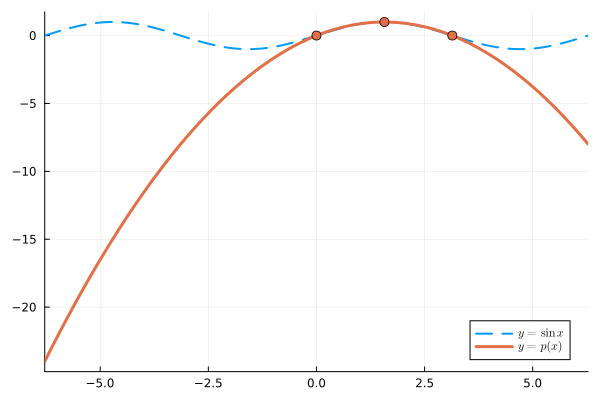

In [6]:
f = x->sin(x)

x = [0, pi/2, pi]
y = f.(x)

p = fit(x,y)
plot(f, -2pi, 2pi,  label=L"y = \sin x", lw=2, linestyle=:dash)
plot!( p, xlims=(-2pi,2pi), label=L"y= p(x)", lw=3)
scatter!( x, y, markersize=5, primary=false)

Derive the same result using the Newton basis $\pi_0 = 1$, $\pi_1 = x$, and $\pi_2 = x(x-\tfrac\pi2)$.


::: {.exercise-solution style="display:none"}

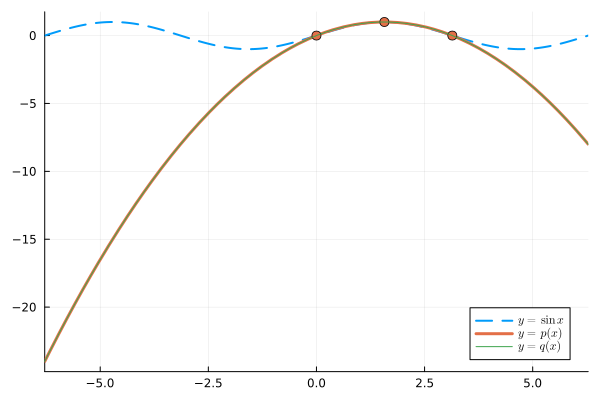

In [7]:
q = (2/π)* Polynomial([0,1,]) - (4/pi^2) * Polynomial( [0, -pi/2, 1] )
plot!(q, xlims=(-2pi,2pi), label=L"y=q(x)")

:::

:::

Notice that if $p$ interpolates $f$ at $X = \{x_0,\dots,x_n\}$ and the $x_j$ are distinct, then

\begin{align}
    p(x) &= a_0 + a_1 (x - x_0) + a_2 (x-x_0)(x-x_1) + \cdots + a_n (x-x_0)(x-x_1) \cdots (x - x_{n-1})\nonumber\\
    %
    &= f(x_0) + \frac{f(x_1) - f(x_0)}{x_1 - x_0} (x-x_0) + a_2 \pi_2(x) + \cdots + a_n \pi_n(x)
\end{align}

::: {#def-divided-diff}

We define the *divided difference* $f[x_{0}, \dots, x_n]$ to be the leading cofficient in the polynomial interpolation $p\in \mathcal P_n$ of $f$ on the set of distinct nodes $X = \{x_0,x_1,\dots, x_n\}$: that is, 

\begin{align}
    p(x) = f[x_0,\dots,x_n] x^n + q(x)
\end{align}

where $q \in \mathcal P_{n-1}$.

:::


We have seen that $f[x_0] = f(x_0)$ and $f[x_0,x_1] = \frac{f(x_1) - f(x_0)}{x_1 - x_0}$. (Here, we just solved $p(x_0) = f(x_0)$ and $p(x_1) = f(x_1)$). 


::: {.callout-note}

**Lemma.** 

The divided difference $f[x_{0}, \dots, x_n]$ doesn't depend on the ordering of the interpolation nodes. Moreover, we have *linearity*: $(f + c g)[x_0,...,x_n] = f[x_0,...,x_n] + c g[x_0,...,x_n]$.



:::
::: {#prf-l08-3}

**Proof.** 

The polynomial interpolant $p\in \mathcal P_n$ of $f$ on $X$ is independent of the ordering of the nodes. 

Moreover, if $p$ and $q$ are the polynomial interpolants of $f$ and $g$, respectively, then $p + c q$ is a polynomial interpolant of $f+ c g$.


:::
::: {#thm-l08-4}

**Theorem.** 

Suppose $X = \{x_0,\cdots,x_n\}$ is a set of $n+1$ distinct interpolation nodes. Then, we have the recursion

\begin{align}
    f[x_0, \dots, x_n] &= \frac
        {f[x_1, \dots, x_n] - f[x_0, \dots, x_{n-1}]}
        {x_n - x_1}
\end{align}


:::
::: {.callout-note}

Let's go back to interpolating $f(x) =\sin x$ on $\{0, \frac\pi2, \pi\}$. Now add $-2\pi$ as an interpolation node and compute the new polynomial interpolant. 

We compute the *divided difference table*:

\begin{align}
    &x_0 = 0,               \quad  &f[x_0] = 0,    \qquad &f[x_0,x_1] = \frac{f[x_1] - f[x_0]}{x_1 - x_0} = \frac{2}\pi, 
    \quad &f[x_0,x_1,x_2] = \frac{f[x_1,x_2] - f[x_0,x_1]}{x_2 - x_0} = -\frac{4}{\pi^2} \nonumber\\ 
    %
    &x_1 = \tfrac\pi2,      \quad  &f[x_1] = 1,     \qquad &f[x_1,x_2] = \frac{f[x_2] - f[x_1]}{x_2 - x_1} = -\frac{2}\pi, 
    \quad &f[x_1,x_2,x_3] = \frac{f[x_2,x_3] - f[x_1,x_2]}{x_3 - x_1} = -\tfrac{4}{5\pi^2} \nonumber\\
    %
    &x_2 = \pi,             \quad &f[x_2] = 0,     \qquad &f[x_2,x_3] =  \frac{f[x_3] - f[x_2]}{x_3 - x_2} = 0 \quad & \nonumber\\
    &x_3 = -2\pi,            \quad &f[x_3] = 0,      \qquad &                                                   \quad & \quad &\nonumber
\end{align}

The final entry on the top row is 

\begin{align}
    f[x_0,x_1,x_2,x_3] &= \frac{f[x_1,x_2,x_3] - f[x_0,x_1,x_2]}{x_3 - x_0}
    =  - \frac{ 8 }{ 5 \pi^3 } \nonumber
\end{align}

and so 

\begin{align}
    p(x) = 0 + \frac{2}\pi x - \frac{4}{\pi^2} x \big(x - \tfrac\pi2\big)  - \frac{ 8 }{ 5 \pi^3 } x\big(x - \tfrac\pi2)\big(x - \pi\big) \nonumber
\end{align}

We plot this below:

 
:::


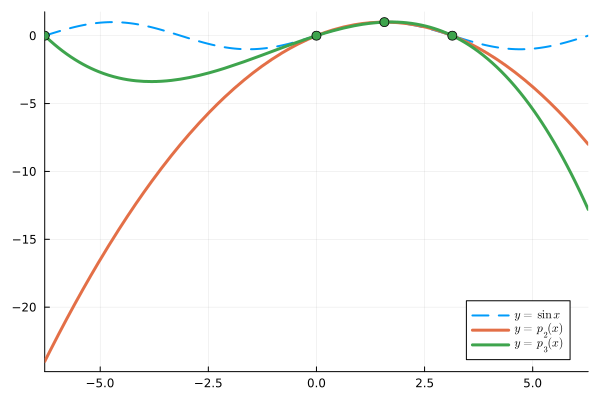

In [8]:
r = x-> - 4*x*(x-pi)/pi^2 - 8*x*(x-pi/2)*(x-pi)/(5*pi^3)

x = [0, pi/2, pi, -2pi]
y = f.(x)

plot(f, -2pi, 2pi,  label=L"y = \sin x", lw=2, linestyle=:dash)
plot!( p, xlims=(-2pi,2pi), label=L"y= p_2(x)", lw=3)
plot!( r, xlims=(-2pi,2pi), label=L"y= p_3(x)", lw=3)
scatter!( x, y, markersize=5, primary=false)

::: {#prf-l08-1}

**Proof.** 

We will now prove the recursive formula. Let $p \in \mathcal P_{n-1}$ be the polynomial interpolation of $f$ on $X = \{x_0,\dots, x_{n-1}\}$ and define $g(x) = (x-x_{n})f(x)$ for some fixed $x_{n} \not\in X$. Then, $g(x)$ and $q(x) := (x - x_{n}) p(x)$ agree on $x_0,...,x_{n-1}, x_{n}$ and so $q$ is the polynomial of least degree interpolating $g$ on $X \cup \{x_{n}\}$. Therefore, the leading coefficient of $q(x) = (x - x_{n}) p(x)$ is both $g[x_0,\dots,x_{n}]$ (because $q$ interpolates $g$ on $X \cup \{x_{n}\}$) and $f[x_0,\cdots,x_{n-1}]$ (because $q$ is $(x-x_{n})$ times $p$). That is, $g[x_0,...,x_{n}] = f[x_0,...,x_{n-1}]$.

That is, we have $\big( (x - x_n) f \big) [x_0,\dots,x_n] = f[x_0,\dots,x_{n-1}]$. By relabeling the indices (which is allowed because $f[x_0,\dots,x_n]$ does not depend on the ordering of the interpolation nodes), we also have $\big( (x - x_0) f \big) [x_0,\dots,x_n] = f[x_1,\dots,x_{n}]$. Therefore, by linearity we have

\begin{align}
    (x_n - x_0) f[x_0,\dots,x_n] &= \big( (x - x_0) f - (x-x_n) f \big) [x_0,\dots,x_n] \nonumber\\
    %
    &= \big( (x - x_0) f \big) [x_0,\dots,x_n] - \big( (x-x_n) f \big) [x_0,\dots,x_n] \nonumber\\
    %
    &= f [x_1,\dots,x_n] - f [x_0,\dots,x_{n-1}] \nonumber
\end{align}

:::


## Hermite Interpolation

Now consider the *multiset* $X = \{\{ x_0, x_1, \dots, x_{n} \}\}$ where $x_j$ appears $m_j \geq 1$ times in $X$.

Hermite: find $p$ such that 

\begin{align}
    p(x_j) = f(x_j),  &\quad p'(x_j) = f'(x_j),  &\quad ... &\quad p^{(m_j-1)}(x_j) = f^{(m_j-1)}(x_j).
\end{align}

::: {#exr-l08-1}

**Exercise.** 

What is the least degree polynomial interpolant on $X = \{x_0, x_0, x_0, \cdots, x_0\}$?

:::
::: {#thm-l08-2}

**Theorem.** 

There exists a unique polynomial of degree at most $n$ solving the Hermite interpolation problem.


:::
Again, we define the divided differences (but now for the more general case where we may have repeated interpolation nodes):

::: {.callout-tip}

**Definition.** 

We define the divided difference $f[x_{0}, \dots, x_n]$ to be the leading cofficient in the polynomial interpolation $p\in \mathcal P_n$ solving the Hermite interpolation problem for $f$ on $X$:

\begin{align}
    p(x) = f[x_0,\dots,x_n] x^n + q(x)
\end{align}

where $q \in \mathcal P_{n-1}$ and $p^{(l)}(x_j) = f^{(l)}(x_j)$ for $l = 0,\dots,m_j-1$.


:::
::: {#thm-l08-4}

**Theorem.** 

We have 

\begin{align}
    f[x_0, \dots, x_n] &= \begin{cases}
    \frac{f^{(n)}(x_0)}{n!} & \text{if } x_0 = x_1 = \dots = x_n \\
    \frac
        {f[x_1, \dots, x_n] - f[x_0, \dots, x_{n-1}]}
        {x_n - x_1} &\text{otherwise}
    \end{cases}
\end{align}

:::
::: {#prf-l08-5}

**Proof.** 

You have seen above that the Taylor polynomial 

\begin{align}
    T_f(x) =\sum_{j=0}^n \frac{f^{(j)}(x_0)}{j!}(x - x_0)^j 
\end{align}

solves the Hermite interpolation problem on $X = \{\{x_0,\dots,x_n\}\}$ in the case where $x_0 = \dots = x_n$. For such $X$, the leading coefficient in this expression is $f[x_{0}, \dots, x_n] = \frac{f^{(n)}(x_0)}{n!}$. 

One can adapt the proof of the recursive formula that we had for distinct interpolation nodes to this case [exercise].


:::
::: {#exr-l08-6}

**Exercise.** 

What is the Hermite interpolant of $f(x) = \sin x$ on $\{\{ 0,0,\pi, \pi\}\}$? Hint: you can compute the divided difference tables in the same way as before.


:::


:::{.callout-tip}
# TO-DO

* Assignment 3 online!
* Exercises throughout the notes,
* (Sign-up to office hours if you like)

:::

## Extra exercises


::: {#exr-l08-bary-weights}

In the notes, we claimed that for the Chebyshev nodes $X_{\mathrm{II}} = \big\{ x_j = \cos\frac{j\pi}{n} \big\}_{j=0}^n$ the barycentric weights $\lambda_j := \big( \prod_{k\not=j} (x_j - x_k) \big)^{-1}$ are given by

\begin{align}
    \lambda_j = \begin{cases}
        \frac{2^{n}}{4n}  & \text{if } j = 0\nonumber\\
        (-1)^j \frac{2^{n}}{2n} & \text{if } j = 1,\dots,n-1 \nonumber\\
        (-1)^n \frac{2^{n}}{4n} & \text{if } j = n
    \end{cases}
\end{align}

Prove the claim as follows:

1. Show that $\lambda_j = 1 / \ell_X'(x_j)$, where $\ell_X(x) = \prod_{k=0}^n (x - x_k)$ is the node polynomial.
2. Show that $T_n'(\cos\theta) = n \frac{\sin n\theta}{\sin\theta}$. Using @exr-l07-XII, deduce that 
$$
    \ell_X(x) = \frac{2^{1-n}}{n} (x^2 - 1) T_n'(x).
$$
3. By differentiating $T_n(\cos\theta) = \cos n\theta$ twice, show that $T_n$ satisfies the *Chebyshev differential equation* 
$$
    (1 - x^2) T_n''(x) - x T_n'(x) + n^2 T_n(x) = 0.
$$
4. Let $w(x) := (x^2-1) T_n'(x)$. Show that 
$$
    w'(x) = x T_n'(x) + n^2 T_n(x).
$$
5. Compute $w'(x_j)$ for $j = 0,\dots,n$ and conclude.
6. Explain why we may replace $\lambda_j$ by $(-1)^j$ (halved for $j = 0, n$) in the barycentric formula. Why is this a good idea when $n$ is large?

::: {.exercise-hint style="display: none;"}

For 5, treat the interior nodes and the endpoints separately: $x_1,\dots,x_{n-1}$ are the points where $T_n$ attains $\pm 1$ in $(-1,1)$. For the endpoints, evaluate the differential equation from 3 at $x = \pm 1$ to find $T_n'(\pm1)$.

:::

::: {.exercise-solution style="display: none;"}

1. Differentiating $\ell_X(x) = (x - x_j) \prod_{k\not=j} (x - x_k)$ with the product rule and setting $x = x_j$ gives $\ell_X'(x_j) = \prod_{k\not=j} (x_j - x_k) = 1/\lambda_j$.

2. Differentiating $T_n(\cos\theta) = \cos n\theta$ gives $-\sin\theta \, T_n'(\cos\theta) = -n \sin n\theta$. Therefore, with $x = \cos\theta$,
$$
    (x^2 - 1) T_n'(x) = -\sin^2\theta \cdot n \frac{\sin n\theta}{\sin \theta} = -n \sin\theta \sin n\theta = \frac{n}{2} \big( T_{n+1}(x) - T_{n-1}(x) \big)
$$
by @exr-l07-XII. Since both sides are polynomials which agree on $[-1,1]$, they are equal, and so $\ell_X(x) = 2^{-n}\big( T_{n+1}(x) - T_{n-1}(x) \big) = \frac{2^{1-n}}{n} (x^2-1) T_n'(x)$.

3. Differentiating $-\sin\theta \, T_n'(\cos\theta) = -n \sin n\theta$ again gives $\sin^2\theta \, T_n''(\cos\theta) - \cos\theta \, T_n'(\cos\theta) = -n^2 \cos n\theta = -n^2 T_n(\cos\theta)$. With $x = \cos\theta$ and $\sin^2\theta = 1 - x^2$, this is the Chebyshev differential equation on $[-1,1]$ and therefore everywhere (both sides are polynomials).

4. By the product rule, $w' = 2x T_n' + (x^2-1) T_n''$. By 3, $(x^2-1) T_n'' = n^2 T_n - x T_n'$ and so $w' = x T_n' + n^2 T_n$.

5. For $j = 1,\dots,n-1$, $T_n(x_j) = \cos j\pi = (-1)^j$ and, since $x_j$ is an interior maximum or minimum of $T_n$, $T_n'(x_j) = 0$. Therefore $w'(x_j) = n^2 (-1)^j$. 

At $x = 1$, the differential equation gives $-T_n'(1) + n^2 T_n(1) = 0$ and so $T_n'(1) = n^2$. Therefore, $w'(x_0) = w'(1) = n^2 + n^2 = 2n^2$. Similarly, at $x = -1$, we have $T_n'(-1) = -n^2 T_n(-1) = (-1)^{n+1} n^2$ and so $w'(x_n) = w'(-1) = (-1)^n n^2 + (-1)^n n^2 = 2 (-1)^n n^2$.

By 1 and 2, $\lambda_j = 1 / \ell_X'(x_j) = \frac{n 2^{n-1}}{w'(x_j)}$, which gives 
\begin{align}
    \lambda_0 = \frac{n 2^{n-1}}{2n^2} = \frac{2^n}{4n}, \qquad 
    \lambda_j = \frac{n 2^{n-1}}{(-1)^j n^2} = (-1)^j \frac{2^n}{2n}, \qquad 
    \lambda_n = \frac{n 2^{n-1}}{2(-1)^n n^2} = (-1)^n \frac{2^n}{4n}. \nonumber
\end{align}

6. The barycentric formula is unchanged if every $\lambda_j$ is multiplied by the same constant $c \not= 0$ (the factor $c$ cancels between the numerator and the denominator). Taking $c = \frac{2n}{2^n}$ gives the weights $(-1)^j$, halved for $j = 0, n$. For large $n$, $2^n$ overflows in floating point arithmetic (for example, `2.0^1024 == Inf`) whereas the rescaled weights are all of size $1$ or $\frac12$.

:::

:::